<a href="https://colab.research.google.com/github/guthasushmasree/ML-LabPrograms/blob/main/ml4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving placement_predict_50k Dataset.csv to placement_predict_50k Dataset.csv
Dataset shape: (50000, 32)

Features:
['CGPA', 'AttendancePercent', 'Internships', 'Projects', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore']

Target distribution:
PlacementStatus
1    32856
0    17144
Name: count, dtype: int64
Training data: (37500, 8)
Testing data : (12500, 8)
Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4286
           1       0.91      0.94      0.92      8214

    accuracy                           0.89     12500
   macro avg       0.89      0.88      0.88     12500
weighted avg       0.89      0.89      0.89     12500

ROC-AUC: 0.9568


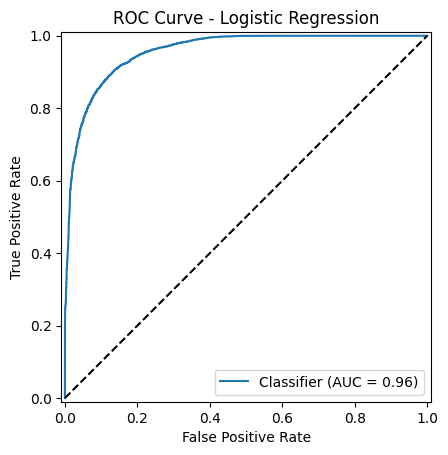

Odds Ratios:
CGPA                  7.766
MockInterviewScore    4.117
SoftSkillsRating      3.445
Internships           1.885
Projects              1.691
AttendancePercent     1.250
AptitudeTestScore     0.943
CodingTestScore       0.519
dtype: float64
Performance Grade Distribution:
grade
Low       17004
High      16992
Medium    16004
Name: count, dtype: int64
Training data: (37500, 7)
Testing data : (12500, 7)
Multinomial Classification Report:

              precision    recall  f1-score   support

        High       0.70      0.73      0.72      4248
         Low       0.70      0.62      0.66      4251
      Medium       0.47      0.51      0.49      4001

    accuracy                           0.62     12500
   macro avg       0.62      0.62      0.62     12500
weighted avg       0.63      0.62      0.62     12500



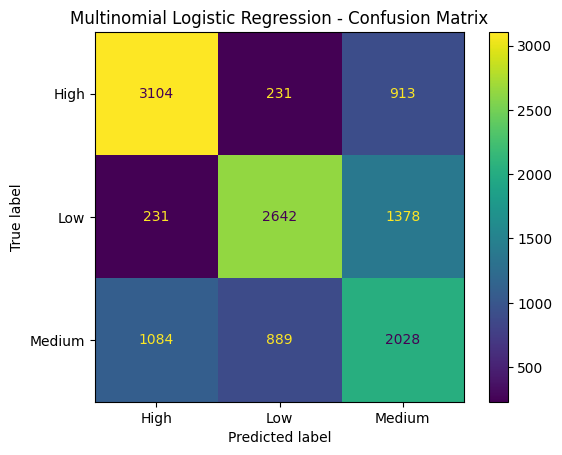

Predicted probabilities for first 5 students:

    High    Low  Medium
0  0.111  0.518   0.371
1  0.661  0.051   0.289
2  0.182  0.353   0.465
3  0.296  0.283   0.421
4  0.706  0.036   0.257


In [ ]:
from google.colab import files

files.upload()
import pandas as pd, matplotlib.pyplot as plt, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

# Load the dataset
df = pd.read_csv("placement_predict_50k Dataset.csv")

# Features used for placement prediction
F = [
    "CGPA",
    "AttendancePercent",
    "Internships",
    "Projects",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]

X = df[F]
y = df["PlacementStatus"]

print("Dataset shape:", df.shape)
print("\nFeatures:")
print(F)
print("\nTarget distribution:")
print(y.value_counts())

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training data:", Xtr.shape)
print("Testing data :", Xte.shape)

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

# Cell 4 - Binary Logistic Regression

# Fill missing values using median
Xtr = Xtr.copy()
Xte = Xte.copy()

for col in Xtr.columns:
    median_value = Xtr[col].median()
    Xtr[col] = Xtr[col].fillna(median_value)
    Xte[col] = Xte[col].fillna(median_value)

# Create Logistic Regression pipeline
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

# Train
clf.fit(Xtr, ytr)

# Predictions
y_pred = clf.predict(Xte)
y_prob = clf.predict_proba(Xte)[:, 1]

# Results
print("Classification Report:\n")
print(classification_report(yte, y_pred))

print("ROC-AUC:",
      round(roc_auc_score(yte, y_prob), 4))

# Cell 5 - ROC Curve

RocCurveDisplay.from_predictions(
    yte,
    y_prob
)

plt.title("ROC Curve - Logistic Regression")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Cell 6 - Odds Ratios

coef = clf[-1].coef_[0]

odds_ratios = pd.Series(
    np.exp(coef),
    index=F
).sort_values(ascending=False)

print("Odds Ratios:")
print(odds_ratios.round(3))

# Cell 7 - Create Low / Medium / High Performance Grades

df["grade"] = pd.cut(
    df["CGPA"],
    bins=[0, 6.5, 8, 10],
    labels=["Low", "Medium", "High"]
)

print("Performance Grade Distribution:")
print(df["grade"].value_counts())

# Cell 8 - Prepare data for Multinomial Logistic Regression

G = [
    "AttendancePercent",
    "Internships",
    "Projects",
    "AptitudeTestScore",
    "SoftSkillsRating",
    "CodingTestScore",
    "MockInterviewScore"
]

X2 = df[G]
y2 = df["grade"]

Xtr2, Xte2, ytr2, yte2 = train_test_split(
    X2,
    y2,
    test_size=0.25,
    random_state=42,
    stratify=y2
)

# Handle missing values
Xtr2 = Xtr2.copy()
Xte2 = Xte2.copy()

for col in Xtr2.columns:
    median_value = Xtr2[col].median()
    Xtr2[col] = Xtr2[col].fillna(median_value)
    Xte2[col] = Xte2[col].fillna(median_value)

print("Training data:", Xtr2.shape)
print("Testing data :", Xte2.shape)

# Cell 9 - Multinomial Logistic Regression

soft = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

soft.fit(Xtr2, ytr2)

pred2 = soft.predict(Xte2)

print("Multinomial Classification Report:\n")
print(classification_report(yte2, pred2))

# Cell 10 - Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(yte2, pred2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=soft.classes_
)

disp.plot()

plt.title("Multinomial Logistic Regression - Confusion Matrix")
plt.show()

# Cell 11 - Predicted Probabilities

probabilities = soft.predict_proba(Xte2[:5])

print("Predicted probabilities for first 5 students:\n")

print(
    pd.DataFrame(
        probabilities.round(3),
        columns=soft.classes_
    )
)